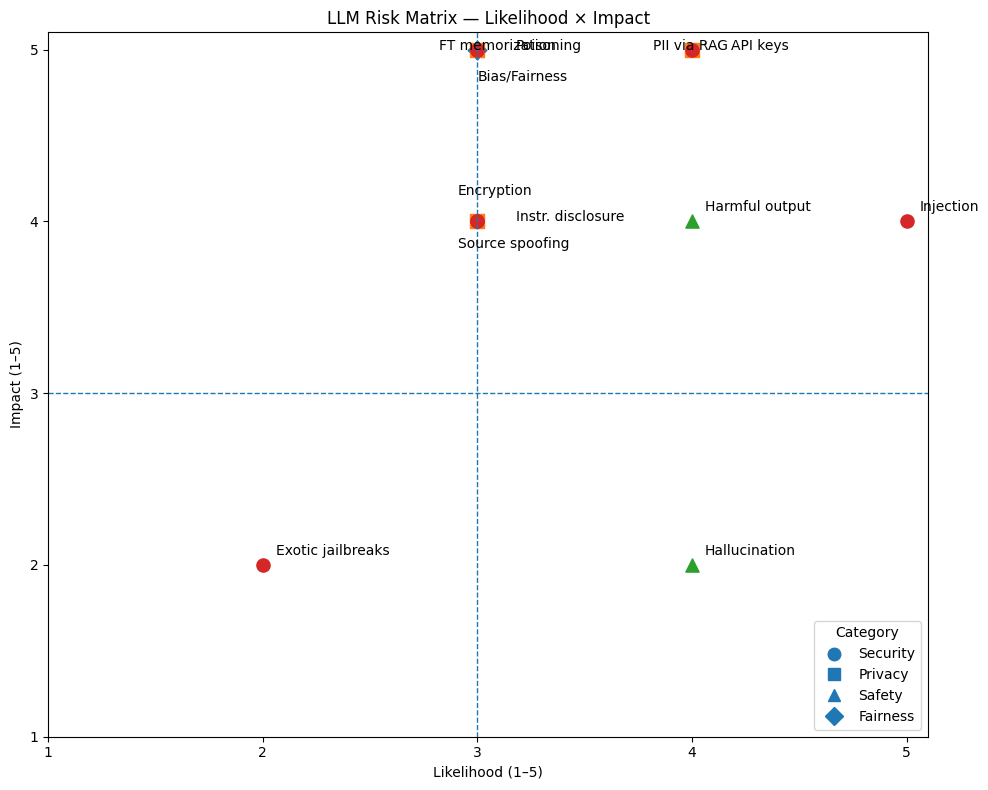

In [2]:
# Risk matrix plot from CSV (Matplotlib only)
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from collections import defaultdict
import math

# --- Load data ---
CSV_PATH = "risk_matrix_data.csv"  # change if needed
df = pd.read_csv(CSV_PATH)

# Optional: quick sanity check
required_cols = {"Risk", "Likelihood", "Impact", "Category"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"CSV missing required columns: {missing}")

# --- Marker shapes by category (no explicit colors) ---
marker_map = {
    "Security": "o",
    "Privacy": "s",
    "Safety": "^",
    "Fairness": "D",
}

# --- Build figure ---
plt.figure(figsize=(10, 8))
ax = plt.gca()

# Quadrant guides at 3 (midpoint of 1–5)
ax.axvline(3, linestyle="--", linewidth=1)
ax.axhline(3, linestyle="--", linewidth=1)

# Scatter by category
for cat, grp in df.groupby("Category"):
    ax.scatter(grp["Likelihood"], grp["Impact"],
               marker=marker_map.get(cat, "o"),
               s=90, label=cat)

# Short labels to keep plot readable
aliases = {
    "Prompt injection": "Injection",
    "API key leakage": "API keys",
    "PII leak via RAG": "PII via RAG",
    "Harmful output / policy violations": "Harmful output",
    "Data poisoning": "Poisoning",
    "Encryption gaps": "Encryption",
    "Platform/system instruction disclosure": "Instr. disclosure",
    "Non-compliance / governance failure": "Non-compliance",
    "FT memorization of sensitive data": "FT memorization",
    "Bias & disparate impact": "Bias/Fairness",
    "Hallucination (non-critical)": "Hallucination",
    "Source spoofing / untrusted sources": "Source spoofing",
    "Exotic jailbreak suffixes": "Exotic jailbreaks",
}

def short_label(name: str) -> str:
    return aliases.get(name, name)

# Avoid label overlap: jitter annotations for points sharing the same (L, I)
buckets = defaultdict(list)
for i, row in df.iterrows():
    buckets[(row["Likelihood"], row["Impact"])].append(i)

offsets = {}
for key, idxs in buckets.items():
    n = len(idxs)
    if n == 1:
        offsets[idxs[0]] = (0.06, 0.06)
    else:
        radius = 0.18
        for k, i in enumerate(idxs):
            angle = 2 * math.pi * (k / n)
            offsets[i] = (radius * math.cos(angle), radius * math.sin(angle))

for i, row in df.iterrows():
    dx, dy = offsets[i]
    ax.annotate(short_label(row["Risk"]),
                (row["Likelihood"] + dx, row["Impact"] + dy),
                fontsize=10)

# Axis styling
ax.set_xlim(1, 5.1)
ax.set_ylim(1, 5.1)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_xlabel("Likelihood (1–5)")
ax.set_ylabel("Impact (1–5)")
ax.set_title("LLM Risk Matrix — Likelihood × Impact")

# Legend (marker shapes only)
handles = [Line2D([0], [0], marker=marker_map[c], linestyle="", markersize=9, label=c)
           for c in marker_map]
ax.legend(handles=handles, title="Category", loc="lower right")

plt.tight_layout()
plt.show()
